## Vizualization

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('framingham .csv')

In [19]:
df_raw = pd.read_csv('framingham.csv')

for col in ['cigsPerDay','totChol','BMI','heartRate','glucose']:
    df_raw[col] = df_raw[col].fillna(df_raw[col].median())
df_raw['BPMeds']    = df_raw['BPMeds'].fillna(0)
df_raw['education'] = df_raw['education'].fillna(df_raw['education'].mode()[0])
df_raw['pulse_pressure']    = df_raw['sysBP'] - df_raw['diaBP']
df_raw['smoking_intensity'] = df_raw['currentSmoker'] * df_raw['cigsPerDay']
df_raw['age_bp']            = df_raw['age'] * df_raw['sysBP']
df_raw['chol_age']          = df_raw['totChol'] * df_raw['age']
df_raw['bmi_age']           = df_raw['BMI'] * df_raw['age']

print(f'Dataset ready: {df_raw.shape}')
print(f'CHD cases: {df_raw.TenYearCHD.sum()} / {len(df_raw)}')

Dataset ready: (4240, 21)
CHD cases: 644 / 4240


## Missing values

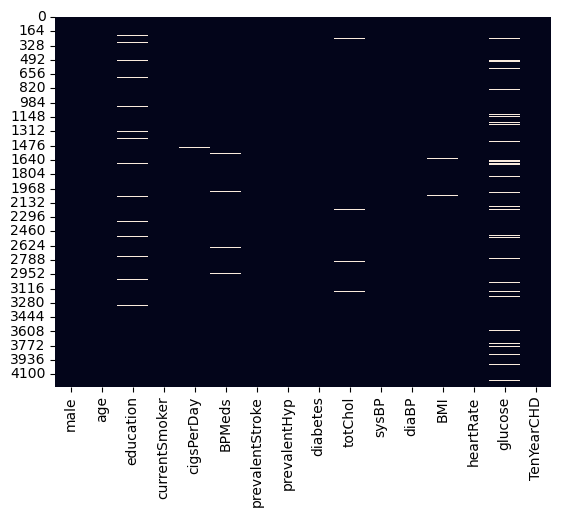

In [20]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

 NO missing values present .The data set is already cleaned

## Feature Correlation Heatmap

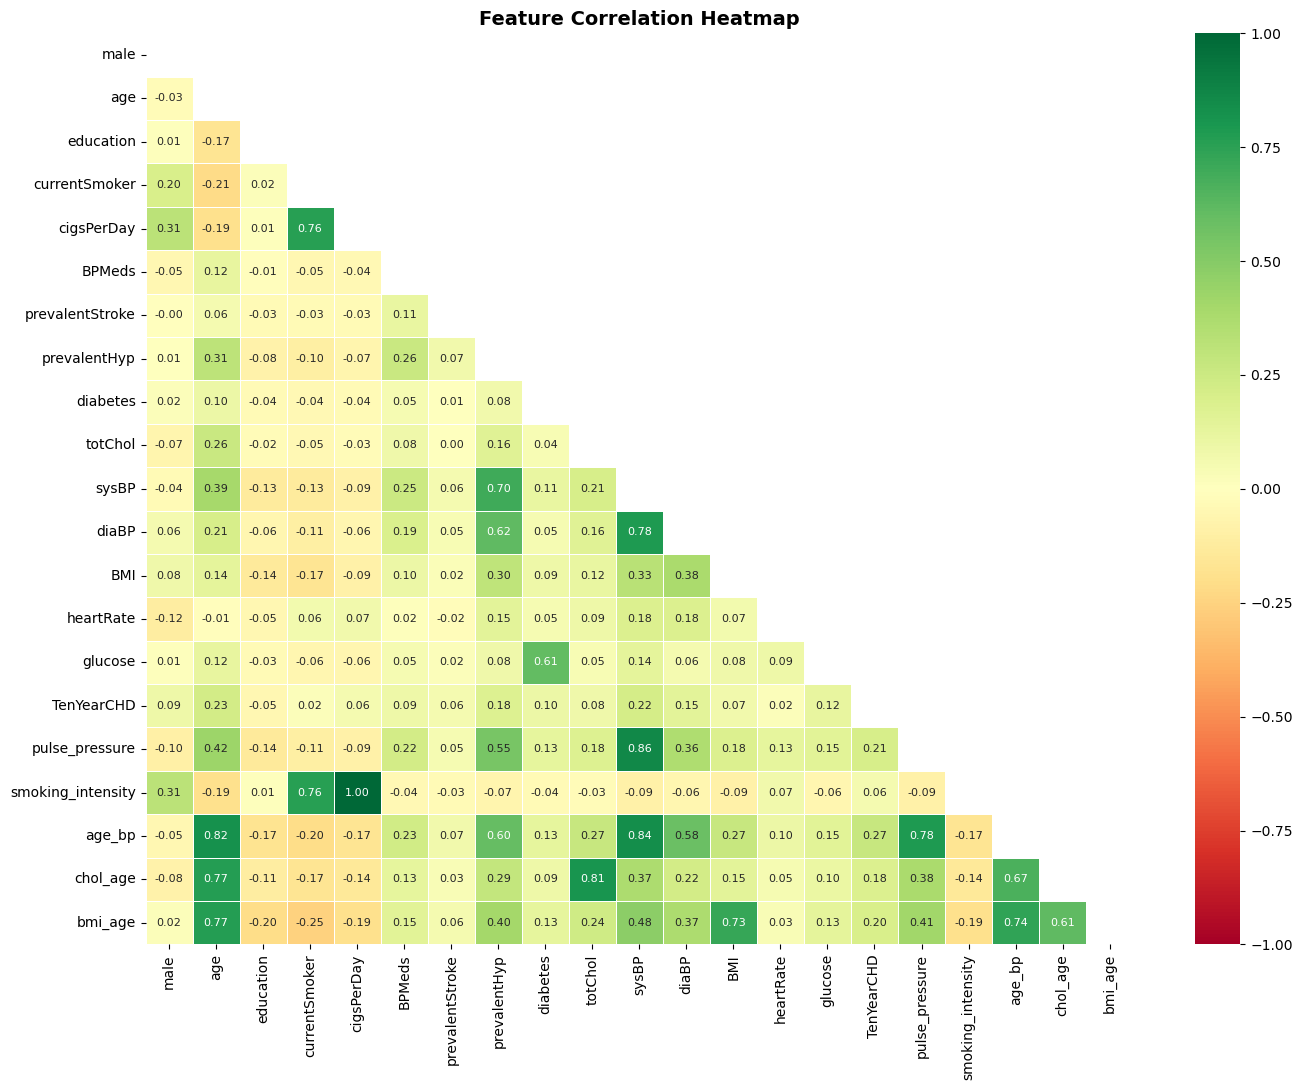

In [21]:
fig,ax= plt.subplots(figsize=(14, 11))
corr = df_raw.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout();
plt.show()

## Correction of all columns with target column

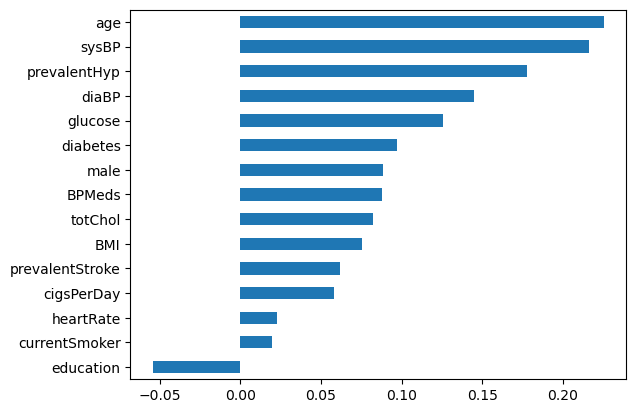

In [22]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()['TenYearCHD'].drop('TenYearCHD')
corr.sort_values().plot(kind='barh')
plt.show()

## CHD by Gender

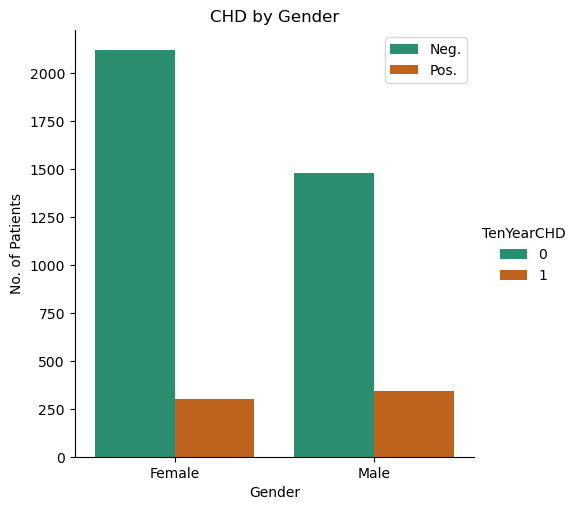

In [23]:
sns.catplot(x='male', hue='TenYearCHD', data=df, kind='count', palette='Dark2', height=5)
plt.xlabel('Gender')
plt.xticks(ticks=[0,1], labels=['Female', 'Male'])
plt.ylabel('No. of Patients')
plt.legend(['Neg.', 'Pos.'])
plt.title('CHD by Gender')
plt.show()

#### Observations
The plot shows CHD distribution by gender.
Most people do not have CHD, indicating a strong negative class.
Females have a higher percentage of non-CHD cases compared to males.
Only a small portion (around 10–15%) of both males and females have CHD.
Overall, the dataset is imbalanced with more negative cases than positive.

## Distributions

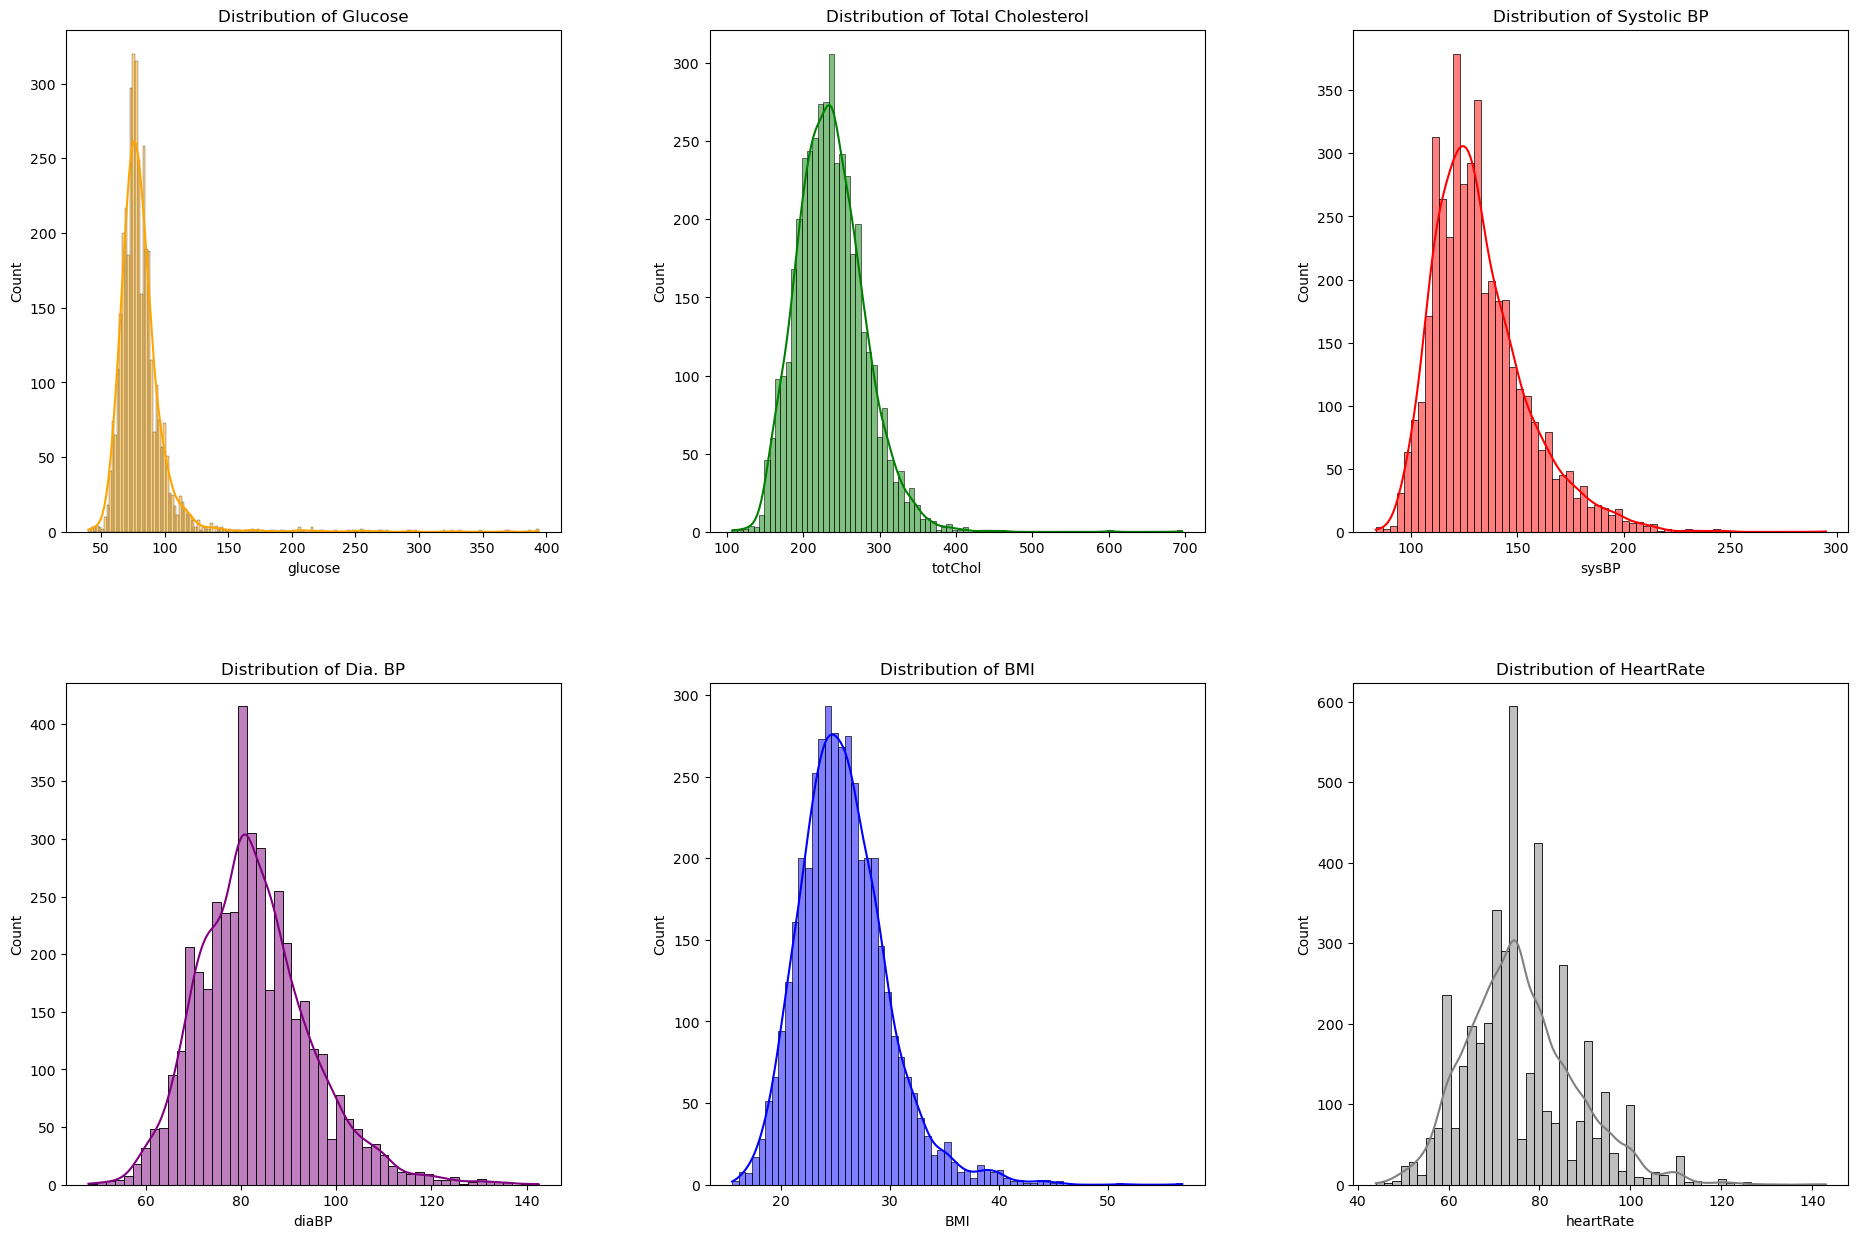

In [24]:
plt.figure(figsize=(23,15))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

plt.subplot(2, 3, 1)
sns.histplot(df['glucose'], kde=True, color='orange')
plt.title('Distribution of Glucose')

plt.subplot(2, 3, 2)
sns.histplot(df['totChol'], kde=True, color='g')
plt.title('Distribution of Total Cholesterol')

plt.subplot(2, 3, 3)
sns.histplot(df['sysBP'], kde=True, color='r')
plt.title('Distribution of Systolic BP')

plt.subplot(2, 3, 4)
sns.histplot(df['diaBP'], kde=True, color='purple')
plt.title('Distribution of Dia. BP')

plt.subplot(2, 3, 5)
sns.histplot(df['BMI'], kde=True, color='blue')
plt.title('Distribution of BMI')

plt.subplot(2, 3, 6)
sns.histplot(df['heartRate'], kde=True, color='grey')
plt.title('Distribution of HeartRate')

plt.show()

#### Observations :
- We can see Glucose, Total Cholesterol, Systolic BP & BMI is Right Skewed.
- While Diastolic BP & Heart Rate are close to Normal / Gaussian Distribution.

## Agewise distribution of the patients

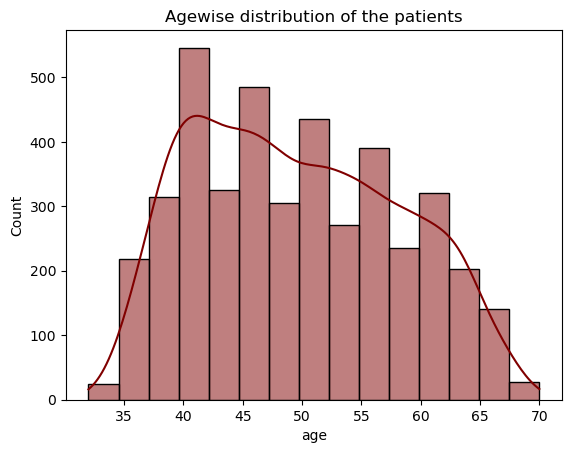

In [25]:
sns.histplot(df['age'], bins=15, kde=True, color='maroon')
plt.ylabel('Count')
plt.title('Agewise distribution of the patients')
plt.show()

#### Observation :
- Subjects ranging from Age 40 to 50 are in Majority followed by 50 to 70.
- Let us define a user-defined Function to encode Age.

## Age-wise Effect on Target (TenYearCHD)

/tmp/ipykernel_4307/1290140529.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_effect = df.groupby('age_group')['TenYearCHD'].mean()


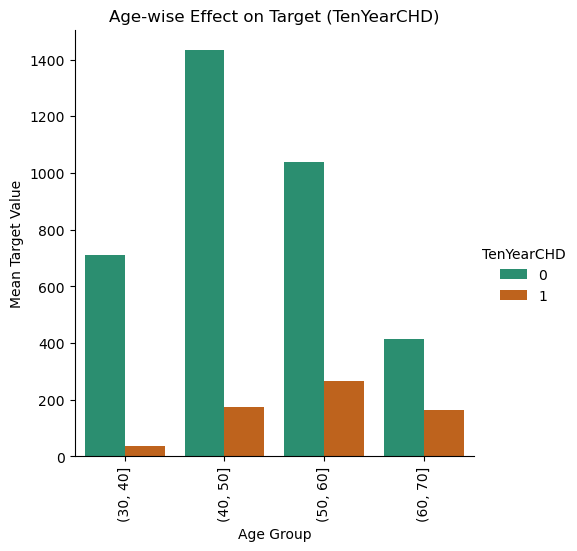

In [26]:

df['age_group'] = pd.cut(df['age'], bins=[30, 40, 50, 60, 70])
age_effect = df.groupby('age_group')['TenYearCHD'].mean()
sns.catplot(x='age_group', hue='TenYearCHD', data=df, kind='count', palette='Dark2', height=5)
plt.title("Age-wise Effect on Target (TenYearCHD)")
plt.xticks(rotation=90,fontsize=10)
plt.xlabel("Age Group")
plt.ylabel("Mean Target Value")

plt.show()

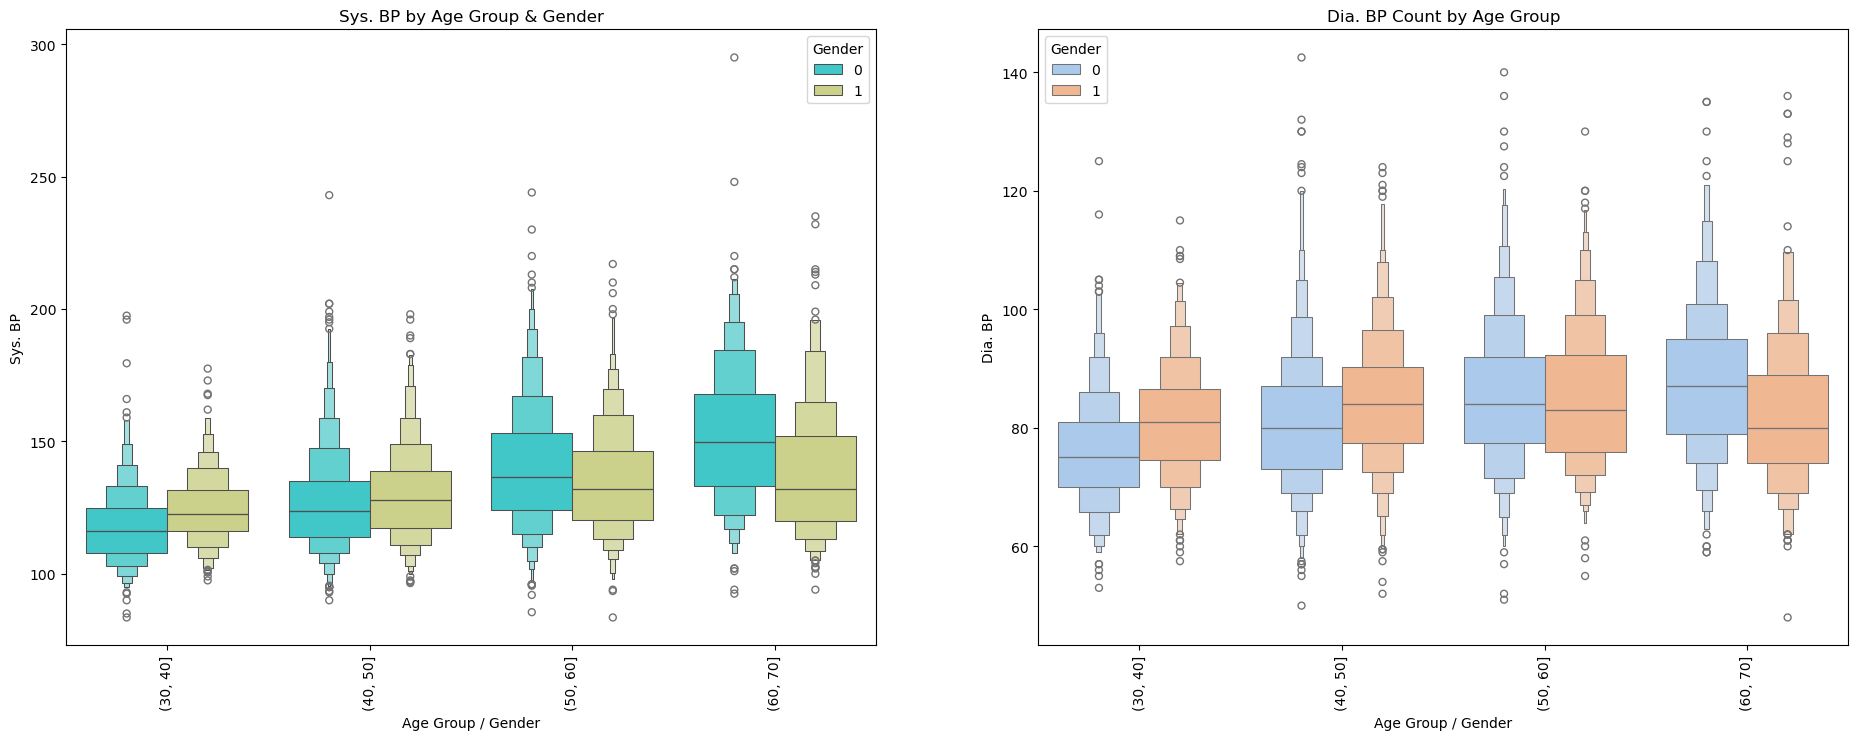

In [27]:
plt.figure(figsize=(23,8))
plt.subplots_adjust(wspace=0.2, hspace=0.3)

plt.subplot(1, 2, 1)
sns.boxenplot(x='age_group', y='sysBP', hue='male', data=df, palette='rainbow')
plt.xlabel('Age Group / Gender')
plt.ylabel('Sys. BP')
plt.xticks(rotation=90)
plt.title('Sys. BP by Age Group & Gender')
plt.legend(title='Gender')

plt.subplot(1, 2, 2)
sns.boxenplot(x='age_group', y='diaBP', hue='male', data=df, palette='pastel')
plt.xlabel('Age Group / Gender')
plt.ylabel('Dia. BP')
plt.xticks(rotation=90)
plt.title('Dia. BP Count by Age Group')
plt.legend(title='Gender')
plt.show()

#### Observations :
- **Sys. BP by Age Group & Gender** : Sys. BP is Increasing by Age Group and Gender.
- **Dia. BP by Age Group & Gender** : Similar to Sys. BP , the Dia. BP is seen Increasing by Age Group & Gender.

<h4>Understanding feature importance on target</h4>

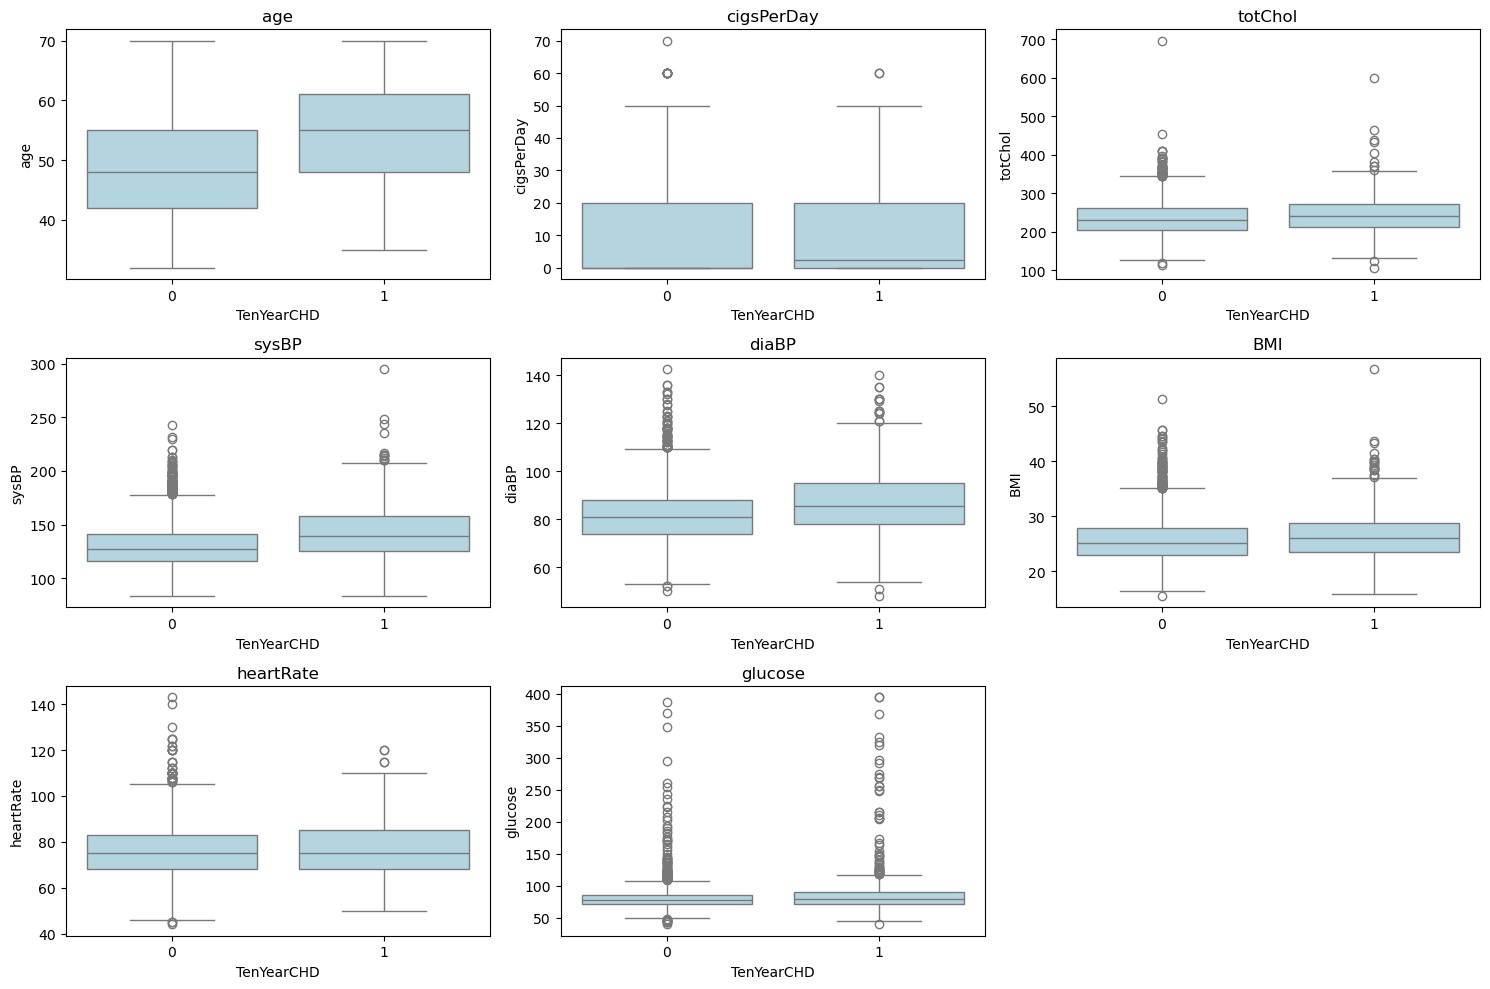

In [28]:
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df["TenYearCHD"],y=df[col], color='lightblue')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

## Target Distribution

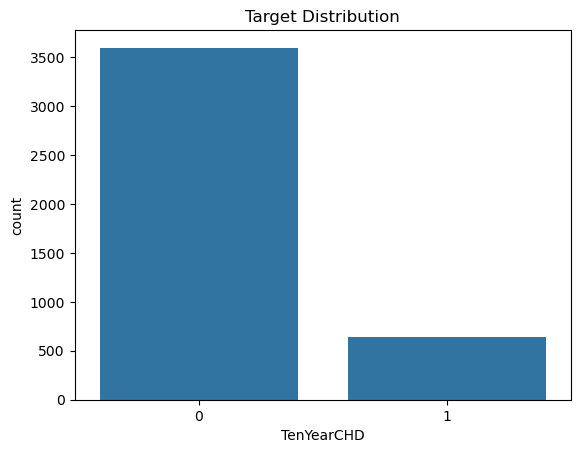

In [29]:
sns.countplot(x='TenYearCHD', data=df)
plt.title("Target Distribution")
plt.show()

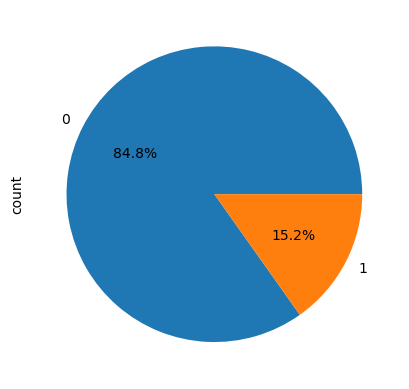

In [30]:
df['TenYearCHD'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

It is a imbalanced data so we have to balance data

## Pair plot

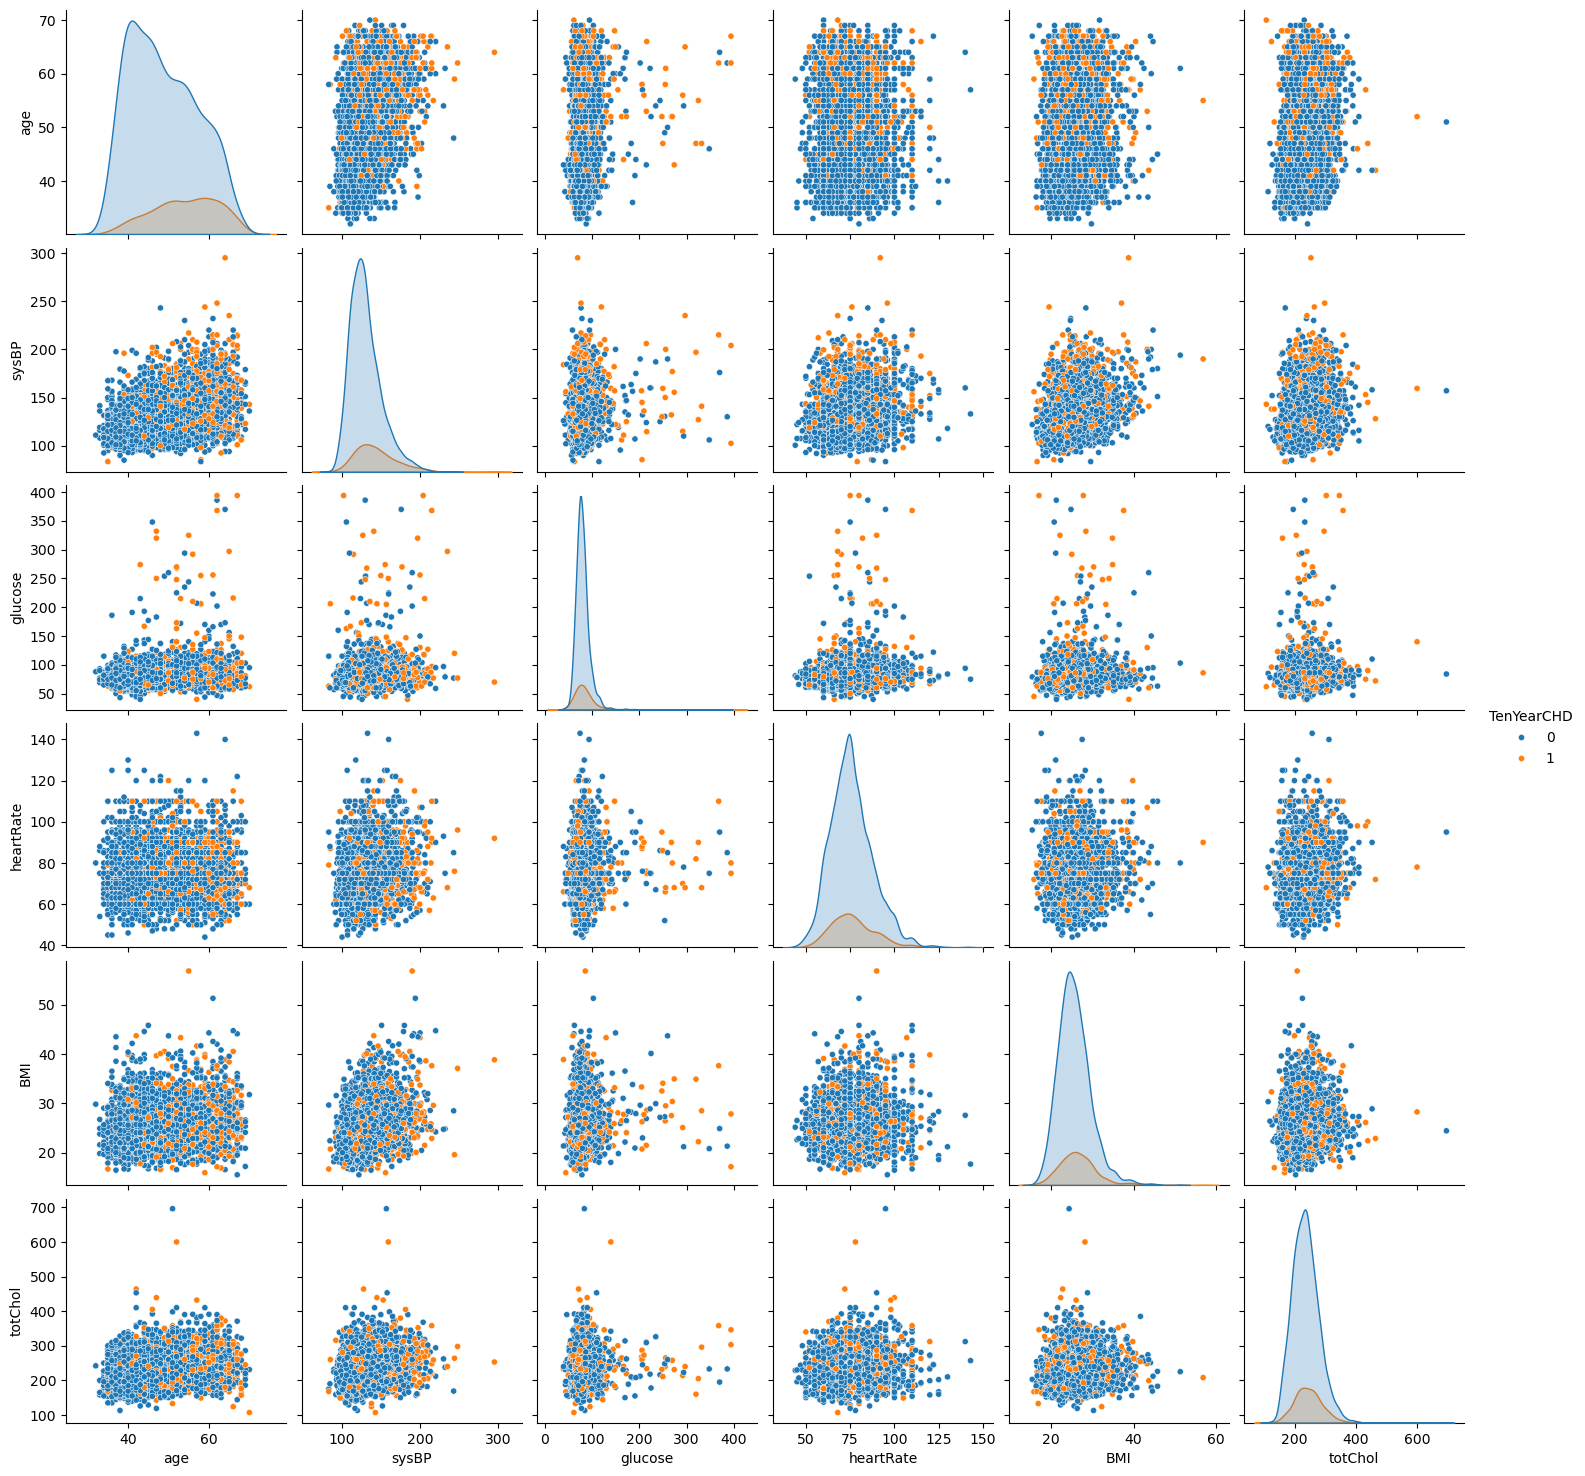

In [31]:
sns.pairplot(df[['age','sysBP','glucose','heartRate','BMI','totChol','TenYearCHD']], hue='TenYearCHD', plot_kws={'s': 20})
plt.show()

## SysBP Vs diaBP

Text(0, 0.5, 'diaBP')

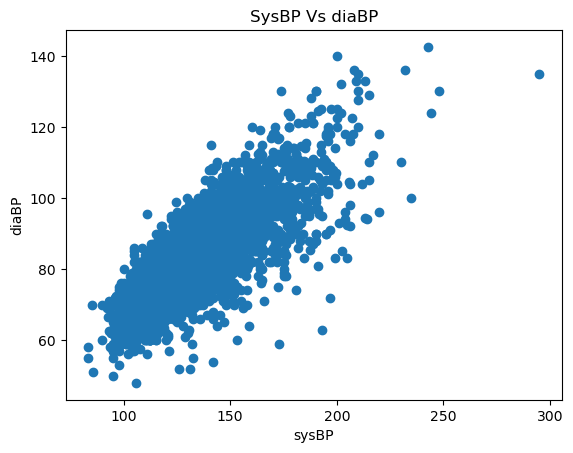

In [32]:
plt.scatter(x="sysBP",y="diaBP",data=df)
plt.title("SysBP Vs diaBP")
plt.xlabel("sysBP")
plt.ylabel("diaBP")

SysBP and diaBP are highly related

## Smoking Impact on CHD

/tmp/ipykernel_4307/3173276016.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cigs_rate = df_raw.groupby('cigs_bin')['TenYearCHD'].mean() * 100


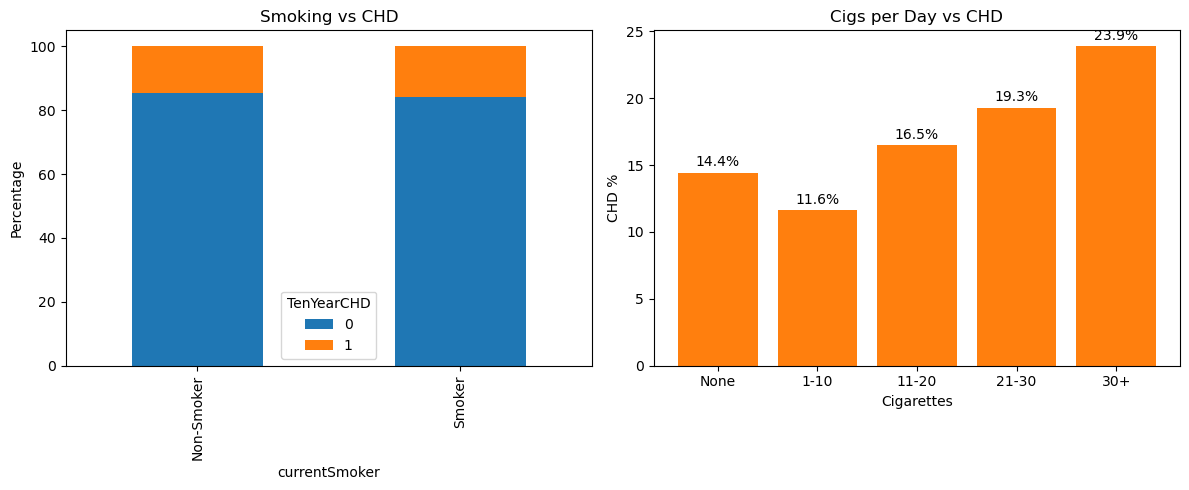

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smoke_chd = pd.crosstab(df_raw['currentSmoker'], df_raw['TenYearCHD'], normalize='index') * 100
smoke_chd.plot(kind='bar', stacked=True, ax=axes[0])

axes[0].set_title('Smoking vs CHD')
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[0].set_ylabel('Percentage')

df_raw['cigsPerDay'] = df_raw['cigsPerDay'].fillna(0)
df_raw['cigs_bin'] = pd.cut(df_raw['cigsPerDay'],bins=[-1,0,10,20,30,100],labels=['None','1-10','11-20','21-30','30+'])
cigs_rate = df_raw.groupby('cigs_bin')['TenYearCHD'].mean() * 100
bars = axes[1].bar(cigs_rate.index.astype(str), cigs_rate.values)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.5,f'{h:.1f}%', ha='center')
axes[1].bar(cigs_rate.index.astype(str), cigs_rate.values)
axes[1].set_title('Cigs per Day vs CHD')
axes[1].set_xlabel('Cigarettes')
axes[1].set_ylabel('CHD %')

plt.tight_layout()
plt.show()

## Heart Rate & Diastolic BP

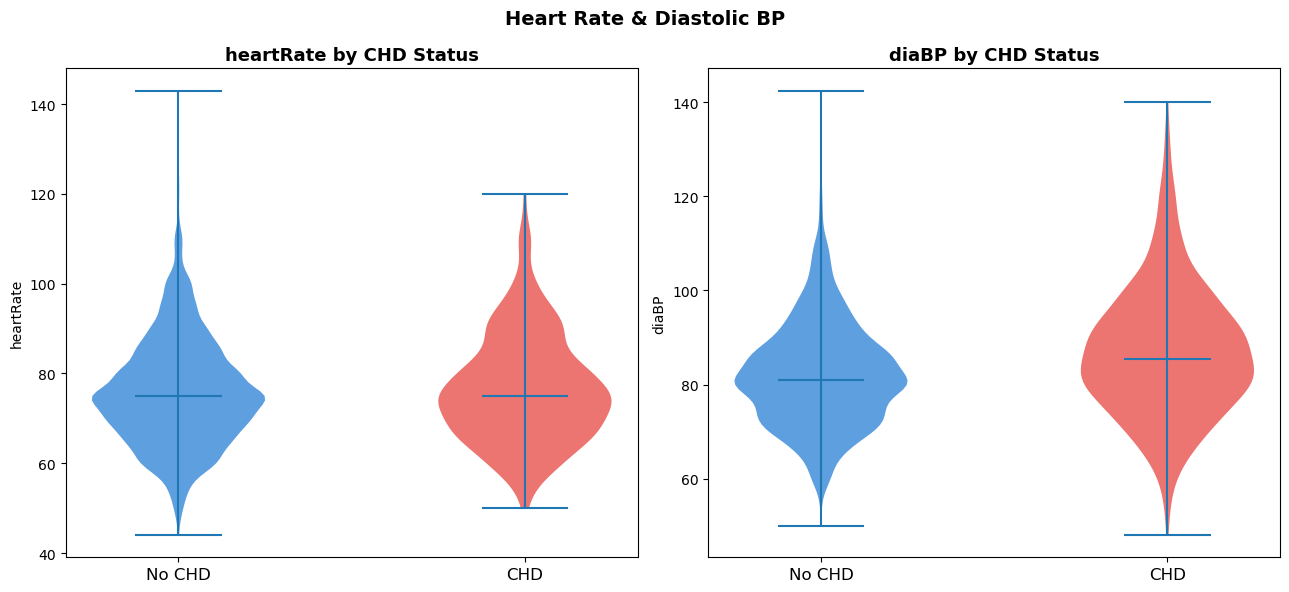

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for col, ax in [('heartRate', axes[0]), ('diaBP', axes[1])]:
    data = [df_raw[df_raw['TenYearCHD']==0][col].dropna(),
            df_raw[df_raw['TenYearCHD']==1][col].dropna()]
    parts = ax.violinplot(data, positions=[1,2], showmedians=True, showextrema=True)
    for pc, clr in zip(parts['bodies'], ['#1976D2', '#E53935']):
        pc.set_facecolor(clr); pc.set_alpha(0.7)
    ax.set_xticks([1,2]); ax.set_xticklabels(['No CHD','CHD'], fontsize=12)
    ax.set_ylabel(col)
    ax.set_title(f'{col} by CHD Status', fontsize=13, fontweight='bold')
fig.suptitle('Heart Rate & Diastolic BP',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Risk Heatmap: Age Group to BP Category

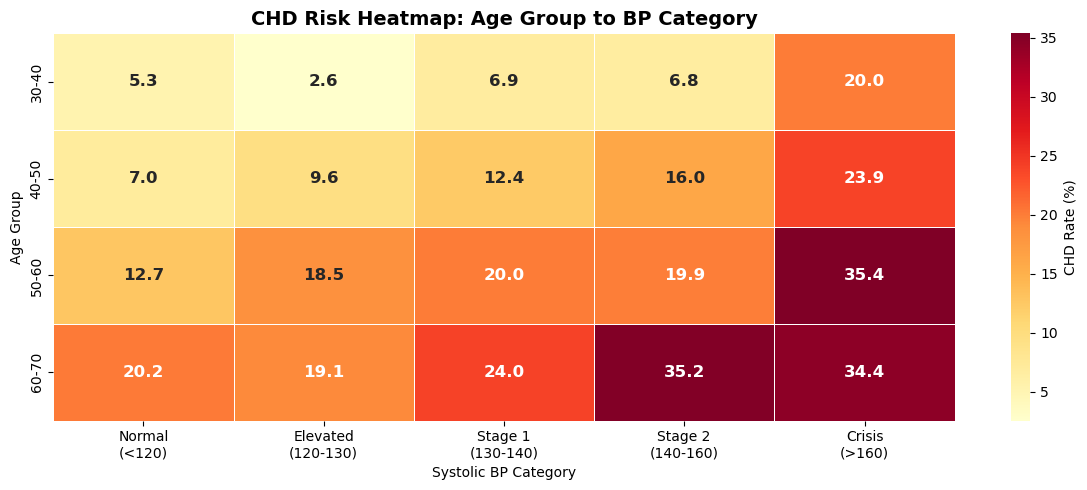

In [35]:
df_h = df_raw.copy()
df_h['age_grp'] = pd.cut(df_h['age'], bins=[30,40,50,60,70],
                           labels=['30-40','40-50','50-60','60-70'])
df_h['bp_cat']  = pd.cut(df_h['sysBP'],
                           bins=[0,120,130,140,160,300],
                           labels=['Normal\n(<120)','Elevated\n(120-130)',
                                   'Stage 1\n(130-140)','Stage 2\n(140-160)','Crisis\n(>160)'])
pivot = df_h.groupby(['age_grp','bp_cat'], observed=True)['TenYearCHD'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'CHD Rate (%)'})
ax.set_xlabel('Systolic BP Category'); ax.set_ylabel('Age Group')
ax.set_title('CHD Risk Heatmap: Age Group to BP Category',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()